# Astrometric weak-lensing sensitivity: galaxy lens and cluster lens

Forecasts for *Discovering Substellar Dark Matter Halos with Astrometric Weak
Lensing of Multiply-Imaged Quasars* (Van Tilburg & Kaplan).

This notebook computes the astrometric response of a macro-image to a population
of dark microhalos and the resulting survey sensitivity, for **both** benchmark
systems:

| Part | System | Lens | Figures produced |
|---|---|---|---|
| I | B1422+231 | galaxy, $z_\mathrm{L}=0.34$, $\sigma_{\delta\theta}=0.1\,\mu$as (EPIC) | `figs/CtildeA.pdf`, `figs/acc.pdf`, `figs/SNR.pdf` |
| II | SDSS J1029+2623 | cluster, $z_\mathrm{L}=0.588$, $\sigma_{\delta\theta}=1\,\mu$as | `figs/CtildeC-J1029.pdf`, `figs/acc-J1029.pdf` |

The two parts share the same machinery (`sensitivity_functions.py`,
`macro_lens_functions.py`); they differ only in the macro-lens model, the
kinematics, the stellar background and the assumed astrometric precision.

**Run order.** Execute the cells top to bottom. Part I needs
`macro_lens_results.npz`, written by `macro_lens.ipynb`. Part II begins with
`from params_J1029_2623 import *`, which deliberately rebinds the system-level
names (`d_lens`, `kappa_fit`, `inv_jacobian_fit`, `labels`, ...) from the galaxy
lens to the cluster lens; Part I must therefore be run *before* Part II, and
re-running a Part I cell afterwards requires re-running Part I from the top.

**Physics conventions** (both parts):

- Halo profile: Gaussian-cutoff $1/r$ cusp, $M_\mathrm{L} = 4\pi\sqrt{e}\,\rho_s r_s^3$,
  form factor $F(k) = e^{-k^2/2}$ (`C_ij_integral`).
- Sweep rate: $\dot{\big(\theta^\mathrm{I}-\theta_h\big)} = B^\mathrm{I}\mu_\mathrm{bulk} - \mu_{h,\mathrm{int}}$.
  Only the *bulk* motion is magnified by $B^\mathrm{I}$; a halo's own orbital motion
  moves the deflector, not the image, and enters unmagnified.
- The stochastic power spectral density $\widetilde{C}^\mathrm{I}_{pq}(\omega)$ is
  Eq. (C) of the paper; the differential acceleration covariance
  $\langle\delta\ddot\theta_{0,p}^\mathrm{I,I'}\delta\ddot\theta_{0,q}^\mathrm{I,I'}\rangle$
  is the smeared $\omega^4$ moment of it (Eq. observable_2).

# Setup

## Packages

In [1]:
from preamble import *
from natural_units_GeV import *
from macro_lens_functions import *
from sensitivity_functions import *
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# import the lens model class 
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions
# import the lens equation solver class (finding image plane positions of a source position)
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
# import lens model solver with 4 image positions constraints
from lenstronomy.LensModel.Solver.solver4point import Solver4Point
from lenstronomy.Util import util

# Part I --- Galaxy lens: B1422+231

Quadruply-imaged quasar at $z_\mathrm{S} = 3.62$ behind a galaxy at
$z_\mathrm{L} = 0.34$, observed with the fiducial EPIC campaign
($\tau = 10\,$yr, $N = 300$, $\sigma_{\delta\theta} = 0.1\,\mu$as).
Produces `figs/CtildeA.pdf`, `figs/acc.pdf` and `figs/SNR.pdf`.

## Parameters

In [2]:
from params_B1422_231 import *

v_obs = np.asarray([0,0]) * km / second
v_lens = v_lens_fid  # BULK fiducial, |v_L| ~ 865 km/s (macro-magnified; see params_B1422_231)
v_source = np.asarray([0,0]) * km / second

vec_mu_source = mu_rel(v_obs, v_lens, v_source, z_lens, z_source, d_lens, d_source, d_lens_source)

# observational parameters
t_int = 10 * year
sigma_delta_theta = 0.1 * muas
N_obs = 300

sigma_mu_fit = 2*np.sqrt(3) * sigma_delta_theta / np.sqrt(N_obs * t_int**2) # proper motion fit uncertainty
sigma_acc_fit = 12*np.sqrt(5) * sigma_delta_theta / np.sqrt(N_obs * t_int**4) # acceleration fit uncertainty

print('sigma_mu_fit = %.2g muas/yr' % (sigma_mu_fit/muasy))
print('sigma_acc_fit = %.2g muas/yr^2' % (sigma_acc_fit/muasyy))

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]
theta_500 =  0.040 muas = 0.195e-12 rad
theta_E_star =  1.400 muas
sigma_mu_fit = 0.002 muas/yr
sigma_acc_fit = 0.0015 muas/yr^2


## Inputs from macro-lens model

In [3]:
filename = 'macro_lens_results.npz'
results = np.load(filename)

kappa_fit = results['kappa_fit']
gamma1_fit = results['gamma1_fit']
gamma2_fit = results['gamma2_fit']
mag_fit = results['mag_fit']
hessian_fit = results['hessian_fit']
jacobian_fit = results['jacobian_fit']
inv_jacobian_fit = results['inv_jacobian_fit']
eigvals_fit = results['eigvals_fit']
eigvecs_fit = results['eigvecs_fit']

In [4]:
fraction_sub = 0.5
kappa_star = 0.05

In [5]:
kappa_l = kappa_fit * fraction_sub # DM microlens convergence at image locations

vec_mu_tilde = np.tensordot(inv_jacobian_fit, vec_mu_source, axes=1) # lensed image proper motion vectors (bulk)
# sweep rate across a subhalo's deflection field: d/dt[theta^I - theta_h] = B mu_bulk - mu_h,int;
# the subhalo's own orbital motion enters UNMAGNIFIED (kinematics fix; see params_B1422_231):
mu_tilde = np.sqrt(np.linalg.norm(vec_mu_tilde, axis=1)**2 + mu_int_drift**2) # image-vs-subhalo sweep rate

# angle of vec_mu_tilde with respect to RA direction
zeta = np.arctan2(vec_mu_tilde[:,1], vec_mu_tilde[:,0])

print('kappa_l =', kappa_l)
print('mu_tilde =', mu_tilde / muasy, 'muas/yr')
print('zeta =', zeta / degree, 'degree')

kappa_l = [0.1923961  0.23139261 0.1834638  0.85749579]
mu_tilde = [0.987289   1.38415754 0.50390606 0.06472893] muas/yr
zeta = [-148.93020601   49.75872011 -106.01920173   76.88233461] degree


# Analytic Power Spectrum

## Power in individual images

### Calculation

In [6]:
vec_omega = np.logspace(-1.3, 1.3, 400) * year**-1  # angular-frequency grid for the PSD figures

vec_M_l = np.asarray([1e-3,1e-4,1e-5,1e-6]) * M_Solar
arr_C_ij_l = np.zeros((len(kappa_l),len(vec_M_l),2,2,len(vec_omega)))

vec_C_star = kappa_star * theta_E_star**2 / vec_omega * np.pi
arr_C_ij_star = np.asarray([[vec_C_star, np.zeros_like(vec_C_star)],[np.zeros_like(vec_C_star),vec_C_star]])
arr_C_pq_star = np.einsum('aqj,apjm->apqm', inv_jacobian_fit,np.einsum('api,ijm->apjm',inv_jacobian_fit, arr_C_ij_star))

vec_C_EPIC = C_EPIC(vec_omega, t_int=t_int, N_obs=N_obs, sigma_delta_theta=sigma_delta_theta)

for j, M_l in enumerate(vec_M_l):
    rho_s = 1e1 * M_Solar * pc**-3; 
    r_s = (M_l/(rho_s *(4*np.pi*np.exp(1/2))))**(1/3) 
    gamma_l = r_s/d_lens;
    theta_E_l = theta_E(M_l, d_lens, d_source, d_lens_source)
    print("theta_E_l = %.3g muas" % (theta_E_l / muas))
    print("r_s = %.2g pc" % (r_s/pc))
    for i in range(len(kappa_l)):
        arr_C_ij_l[i,j] = kappa_l[i] * theta_E_l**2 / vec_omega * C_ij_integral(gamma_l/mu_tilde[i] * vec_omega, zeta[i])
arr_C_pq_l = np.einsum('aqj,abpjm->abpqm',inv_jacobian_fit, np.einsum('api,abijm->abpjm', inv_jacobian_fit, arr_C_ij_l)) # implement macrolensing of power spectrum

theta_E_l = 0.0809 muas
r_s = 0.017 pc
theta_E_l = 0.0256 muas
r_s = 0.0078 pc
theta_E_l = 0.00809 muas
r_s = 0.0036 pc
theta_E_l = 0.00256 muas
r_s = 0.0017 pc


### Plots

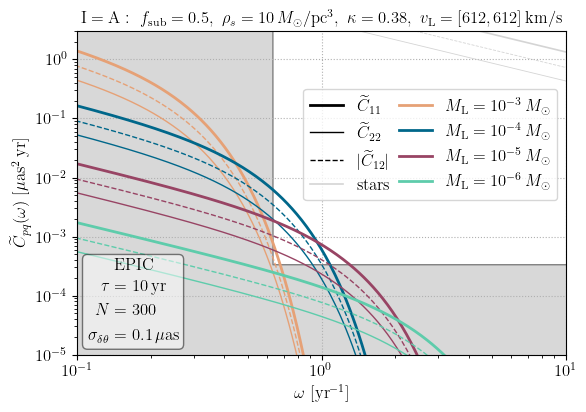

In [7]:
fig,ax = plt.subplots(1,1,figsize=(6.3,4.2))
#colors = sns.color_palette("husl", 4)
colors = [sns.color_palette(xgfs_fancy6)[i] for i in [2,3,4,5,6]]

ax.plot(vec_omega/year**-1, 0*arr_C_pq_l[0,0,0,0]/(muas**2*year), color='k', lw=2, 
        label=r'$\widetilde{C}_{11}$')
ax.plot(vec_omega/year**-1, 0*arr_C_pq_l[0,0,1,1]/(muas**2*year), color='k', lw=1,
        label=r'$\widetilde{C}_{22}$')
ax.plot(vec_omega/year**-1, 0*np.abs(arr_C_pq_l[0,0,0,1])/(muas**2*year), color='k',lw=1,ls='dashed',
        label=r'$|\widetilde{C}_{12}|$')

idx_l = 0
for i in [idx_l]:
        
        # naive stellar PSD: plotted de-emphasized, since the stars are measured and
        # subtracted star by star via intensity-interferometric shape fits (companion paper)
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,0,0]/(muas**2*year), color=colors[4], lw=1.2, alpha=0.85,
                label='stars')
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,1,1]/(muas**2*year), color=colors[4], lw=0.6, alpha=0.85)
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,0,1]/(muas**2*year), color=colors[4], lw=0.6, alpha=0.85, ls='dashed')
        
        for j, M_l in enumerate(vec_M_l):
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,0,0]/(muas**2*year), color=colors[j], lw=2, 
                        label=r'$M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,1,1]/(muas**2*year), color=colors[j], lw=1)
                        #label=r'$C^\mathrm{DM}_{22}, M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))
                ax.plot(vec_omega/year**-1, np.abs(arr_C_pq_l[i,j,0,1])/(muas**2*year), color=colors[j],lw=1,ls='dashed')
                        #label=r'$C^\mathrm{DM}_{12}, M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))

ax.fill_between(vec_omega/year**-1,vec_C_EPIC/(muas**2*year),
                color=(0.5,0.5,0.5,1), facecolor=(0.5,0.5,0.5,0.3), ls='solid',lw=1)#label=r'$\mathrm{EPIC}$')


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\omega~ [\mathrm{yr}^{-1}$]')
ax.set_ylabel(r'$\widetilde{C}_{pq}(\omega) ~[\mathrm{\mu as^2 \, yr}]$')
ax.grid(ls='dotted')
ax.set_xlim(1e-1,1e1);
ax.set_ylim(1e-5,3e0)
ax.legend(loc='center right', bbox_to_anchor=(1, 0.65),ncol=2,labelspacing=0.5, columnspacing=0.5);
ax.text(1.1e-1,1.5e-5,
        r'\begin{align*} \text{EPIC} \end{align*} \vspace{-3em} \begin{align*}\tau &= %.5g \,\mathrm{yr} \\ N &= %.5g \\ \sigma_{\delta \theta} &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((t_int/year),(N_obs),(sigma_delta_theta/muas)),
        ha='left',va='bottom',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5));
ax.set_title(r'$\text{I}=\mathrm{%s}: ~f_\mathrm{sub} = %.1g, ~\rho_s = %.2g \,M_\odot/\mathrm{pc^3}, ~\kappa = %.2g, ~v_\mathrm{L} = [%.3g,%.3g] \,\mathrm{km/s}$'
              % (labels[idx_l], fraction_sub, (rho_s/(M_Solar/pc**3)), kappa_fit[idx_l], (v_lens[0]/(km/second)), (v_lens[1]/(km/second))),
              fontsize=12);
fig.savefig('../figs/CtildeA.pdf', bbox_inches='tight')

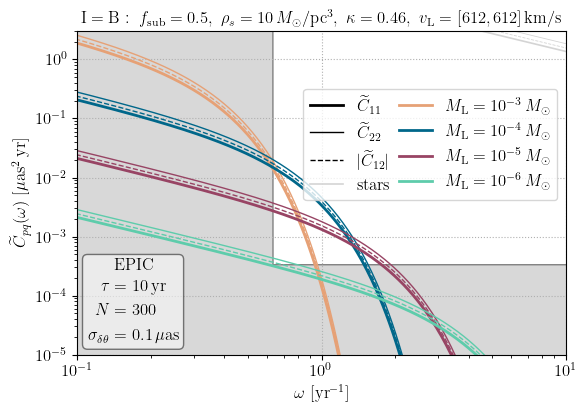

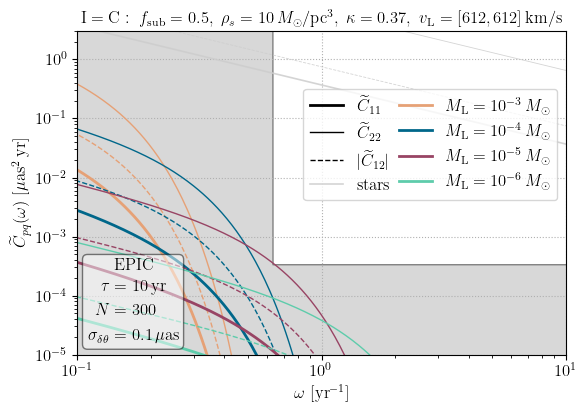

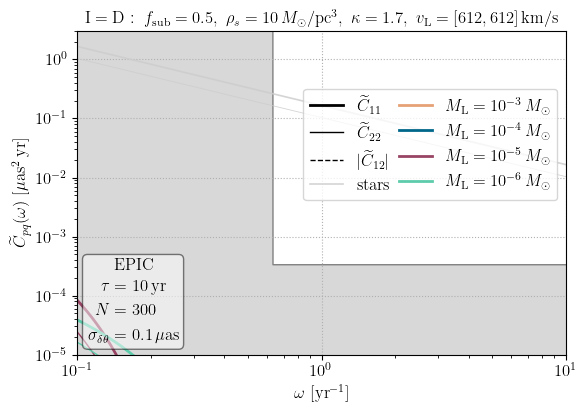

In [8]:
# same PSD, for the remaining images B, C, D (diagnostic; not saved to figs/)
for idx_l in [1, 2, 3]:
    fig,ax = plt.subplots(1,1,figsize=(6.3,4.2))
    #colors = sns.color_palette("husl", 4)
    colors = [sns.color_palette(xgfs_fancy6)[i] for i in [2,3,4,5,6]]

    ax.plot(vec_omega/year**-1, 0*arr_C_pq_l[0,0,0,0]/(muas**2*year), color='k', lw=2, 
            label=r'$\widetilde{C}_{11}$')
    ax.plot(vec_omega/year**-1, 0*arr_C_pq_l[0,0,1,1]/(muas**2*year), color='k', lw=1,
            label=r'$\widetilde{C}_{22}$')
    ax.plot(vec_omega/year**-1, 0*np.abs(arr_C_pq_l[0,0,0,1])/(muas**2*year), color='k',lw=1,ls='dashed',
            label=r'$|\widetilde{C}_{12}|$')

    for i in [idx_l]:
        
            # naive stellar PSD: plotted de-emphasized, since the stars are measured and
            # subtracted star by star via intensity-interferometric shape fits (companion paper)
            ax.plot(vec_omega/year**-1, arr_C_pq_star[i,0,0]/(muas**2*year), color=colors[4], lw=1.2, alpha=0.85,
                    label='stars')
            ax.plot(vec_omega/year**-1, arr_C_pq_star[i,1,1]/(muas**2*year), color=colors[4], lw=0.6, alpha=0.85)
            ax.plot(vec_omega/year**-1, arr_C_pq_star[i,0,1]/(muas**2*year), color=colors[4], lw=0.6, alpha=0.85, ls='dashed')
        
            for j, M_l in enumerate(vec_M_l):
                    ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,0,0]/(muas**2*year), color=colors[j], lw=2, 
                            label=r'$M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))
                    ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,1,1]/(muas**2*year), color=colors[j], lw=1)
                            #label=r'$C^\mathrm{DM}_{22}, M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))
                    ax.plot(vec_omega/year**-1, np.abs(arr_C_pq_l[i,j,0,1])/(muas**2*year), color=colors[j],lw=1,ls='dashed')
                            #label=r'$C^\mathrm{DM}_{12}, M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))

    ax.fill_between(vec_omega/year**-1,vec_C_EPIC/(muas**2*year),
                    color=(0.5,0.5,0.5,1), facecolor=(0.5,0.5,0.5,0.3), ls='solid',lw=1)#label=r'$\mathrm{EPIC}$')


    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\omega~ [\mathrm{yr}^{-1}$]')
    ax.set_ylabel(r'$\widetilde{C}_{pq}(\omega) ~[\mathrm{\mu as^2 \, yr}]$')
    ax.grid(ls='dotted')
    ax.set_xlim(1e-1,1e1);
    ax.set_ylim(1e-5,3e0)
    ax.legend(loc='center right', bbox_to_anchor=(1, 0.65),ncol=2,labelspacing=0.5, columnspacing=0.5);
    ax.text(1.1e-1,1.5e-5,
            r'\begin{align*} \text{EPIC} \end{align*} \vspace{-3em} \begin{align*}\tau &= %.5g \,\mathrm{yr} \\ N &= %.5g \\ \sigma_{\delta \theta} &= %.5g \, \mathrm{ \mu as} \end{align*}'
            % ((t_int/year),(N_obs),(sigma_delta_theta/muas)),
            ha='left',va='bottom',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5));
    ax.set_title(r'$\text{I}=\mathrm{%s}: ~f_\mathrm{sub} = %.1g, ~\rho_s = %.2g \,M_\odot/\mathrm{pc^3}, ~\kappa = %.2g, ~v_\mathrm{L} = [%.3g,%.3g] \,\mathrm{km/s}$'
                  % (labels[idx_l], fraction_sub, (rho_s/(M_Solar/pc**3)), kappa_fit[idx_l], (v_lens[0]/(km/second)), (v_lens[1]/(km/second))),
                  fontsize=12);
    plt.show()

# Sensitivity

## Stellar background

In [9]:
# ---- Stellar microlensing background: companion-paper results rescaled to this survey ----
# Ref. [companionstars] fits stellar microlenses through their II image-shape distortions
# out to theta_fit = 10 muas (for M_* = 0.3 Msun) over a 33-epoch, 8-yr campaign. Detection
# accumulates as chi^2 ~ n_obs (gamma_* SNR_1)^2 with shear gamma_* = (theta_E*/theta_sep)^2,
# so theta_fit ~ theta_E* SNR_1^(1/2) n_obs^(1/4). Rescaled to the N_obs epochs assumed here:
n_obs_companion = 33
theta_fit = 10 * muas * (N_obs / n_obs_companion)**0.25
print('theta_fit = %.3g muas' % (theta_fit/muas))

N_fit = kappa_star * Sigma_crit(d_lens, d_source, d_lens_source) / M_star * np.pi * theta_fit**2 * d_lens**2
print('N_fit = %.2g (image A, kappa_* = %.3g)' % (N_fit, kappa_star))

Delta_theta = mu_tilde * t_int
print('Delta_theta = %.2g muas (image A)' % (Delta_theta[0]/muas))
print('theta_E_star = %.2g muas' % (theta_E_star/muas))

# Two residual terms, studied for image A only (adopted below as the per-image estimate):
# (1) worst-case acceleration variance from the nearest UNFITTED star, placed at theta_fit
#     (Eq. 3.24 of VanTilburg:2018ykj): ~ theta_fit^-6 ~ SNR_1^-3 n_obs^-3/2 -- falls
#     FASTER than the instrumental floor.
sigma2_acc_unfitted_A = np.abs(np.linalg.det(inv_jacobian_fit[0])) * 4 * theta_E_star**4 * mu_tilde[0]**4 / theta_fit**6
# (2) FITTED-star subtraction residual: best-case variance 1.96e-4 muas^2/yr^4 over the
#     companion campaign; scales as sigma_c^2/(n_obs tau^4), i.e. like the instrumental floor.
sigma2_acc_fitted_A = 1.96e-4 * muasyy**2 * (n_obs_companion/N_obs) * ((8*year)/t_int)**4
sigma2_acc_star_A = sigma2_acc_unfitted_A + sigma2_acc_fitted_A
print('image A: unfitted = %.3g, fitted = %.3g, total = %.3g muas^2/yr^4'
      % (sigma2_acc_unfitted_A/muasyy**2, sigma2_acc_fitted_A/muasyy**2, sigma2_acc_star_A/muasyy**2))


theta_fit = 17.4 muas
N_fit = 7.7 (image A, kappa_* = 0.05)
Delta_theta = 9.9 muas (image A)
theta_E_star = 1.4 muas
image A: unfitted = 3.66e-06, fitted = 8.83e-06, total = 1.25e-05 muas^2/yr^4


## Instrument-limited

In [10]:
sigma_acc_EPIC = np.sqrt(720 * sigma_delta_theta**2 / (t_int**4 * N_obs))

print(r'sigma_acc_EPIC^2 = %.2g muas^2/yr^4' % (sigma_acc_EPIC**2/muasyy**2))
print(r'sigma_acc_EPIC = %.2g muas/yr^2' % (sigma_acc_EPIC/muasyy))

sigma_acc_EPIC^2 = 2.4e-06 muas^2/yr^4
sigma_acc_EPIC = 0.0015 muas/yr^2


\begin{align}
C^\mathrm{AB}_{ij} = \langle (\theta^\mathrm{A}_i - \theta^\mathrm{B}_i) (\theta^\mathrm{A}_j - \theta^\mathrm{B}_j) \rangle = C^\mathrm{A}_{ij} + C^\mathrm{B}_{ij}
\end{align}

Compute eigenvalues of $C_{ij}^\mathrm{AB}$, compare largest to $C_{ii}^\mathrm{EPIC}$ (no sum) at the most favorable frequency. When SNR > 1, that parameter space point of $\kappa_l$, $M_l$, $r_s$ is detectable.

Fixed velocity for now, marginalize over velocity later. Also better to do weighted sum in SNR, though lowest signal frequency dominates.



### Setup

In [11]:
f_sub = 1
list_r_s = 10**np.arange(-4.5,1.5,0.04) * pc
list_rho_s = 10**np.arange(-2.,5.01,0.04) * M_Solar/pc**3
arr_r_s, arr_rho_s = np.meshgrid(list_r_s, list_rho_s)
arr_M_l = np.asarray([[4*np.pi*np.exp(1/2) * rho_s * r_s**3 for r_s in list_r_s] for rho_s in list_rho_s])
arr_gamma_l = arr_r_s / d_lens
arr_theta_E_l = theta_E(arr_M_l, d_lens, d_source, d_lens_source)
list_n = np.arange(1,N_obs)
list_omega = 2 * np.pi / t_int * list_n # list of angular frequencies sampled in DFT
list_omega_out = np.logspace(-6,2,int(5e2)) * 2 * np.pi / t_int # list of angular frequencies outside of DFT (for proper motion and acceleration integrals)

arr_crit = arr_rho_s * arr_r_s / Sigma_crit(d_lens, d_source, d_lens_source) # critical surface density (crude estimate)


# predictions
list_M_200 = 10**np.arange(-10.,8,0.1) * M_Solar
list_r_s_pred = r_s_Einasto_200(list_M_200)
list_rho_s_pred = 20*rho_s_Einasto_200(list_M_200)
list_M_s_pred = M_enc_Einasto(list_r_s_pred, list_rho_s_pred, list_r_s_pred)


In [12]:
len(list_rho_s),len(list_r_s), np.shape(arr_gamma_l), np.shape(arr_M_l), len(list_omega)

(176, 150, (176, 150), (176, 150), 299)

### Scan for temporal power spectrum

In [13]:
arr_C_ij_l = np.zeros((len(kappa_l),len(list_rho_s),len(list_r_s),2,2,len(list_omega)))
for i in range(len(kappa_l)):
    arr_C_ij_l[i] = f_sub * kappa_l[i] * arr_theta_E_l[:,:,None,None,None]**2 / list_omega * np.transpose(C_ij_integral(arr_gamma_l[:,:,None]/mu_tilde[i] * list_omega, zeta[i]),axes=(2,3,0,1,4))
arr_C_pq_l = np.einsum('aqj,abcpjm->abcpqm',inv_jacobian_fit, np.einsum('api,abcijm->abcpjm', inv_jacobian_fit, arr_C_ij_l)) # implement macrolensing of power spectrum

# added power spectra for all image pairs
N_images = len(kappa_l)
N_pairs = N_images * (N_images - 1) // 2
arr_Delta_C_pq_l = np.zeros((N_pairs,len(list_rho_s),len(list_r_s),2,2,len(list_omega))) # shape = N_pairs, len(list_rho_s), len(list_r_s), 2, 2,  len(list_omega)

count = 0
for i in range(N_images):
    for j in range(i+1,N_images):
        arr_Delta_C_pq_l[count] = arr_C_pq_l[i] + arr_C_pq_l[j]
        count+=1

arr_Delta_C_pq_l = np.transpose(arr_Delta_C_pq_l, axes=(1,2,0,5,3,4)) # reshape = len(list_rho_s), len(list_r_s), N_pairs, len(list_omega), 2, 2
arr_Delta_C_mag_l = np.max(np.linalg.eigvals(arr_Delta_C_pq_l),axis=-1) # magnitude of largest eigenvalue

arr_C_EPIC = C_EPIC(list_omega, t_int=t_int, N_obs=N_obs, sigma_delta_theta=sigma_delta_theta) #[None,None,None,:]

arr_SNR_EPIC = np.max(arr_Delta_C_mag_l / arr_C_EPIC, axis=(-2,-1))

### Subtraction

In [14]:
cos_fac = (12/N_obs**2) / (1 - np.cos(2 * np.pi * list_n / N_obs))
arr_Delta_C_mag_tilde = (1 - cos_fac) * arr_Delta_C_mag_l #+ (1/2) * cos_fac * np.sum(cos_fac * arr_Delta_C_mag_l, axis=-1)[:,:,:,None]
arr_SNR_EPIC_tilde = np.max(arr_Delta_C_mag_tilde / arr_C_EPIC, axis=(-2,-1))

### Scan for proper motion and acceleration

In [15]:
def smear_fac_mu(a):
    return np.heaviside(-a + 1e-2,0) + np.heaviside(a - 1e-2,0) * 144 * (a * np.cos(a/2) - 2 * np.sin(a/2))**2 / a**6
def smear_fac_acc(a):
    return np.heaviside(-a + 1e-2,0) + np.heaviside(a - 1e-2,0) * 14400 * (6 * a * np.cos(a/2) + (-12 + a**2) * np.sin(a/2))**2 / a**10

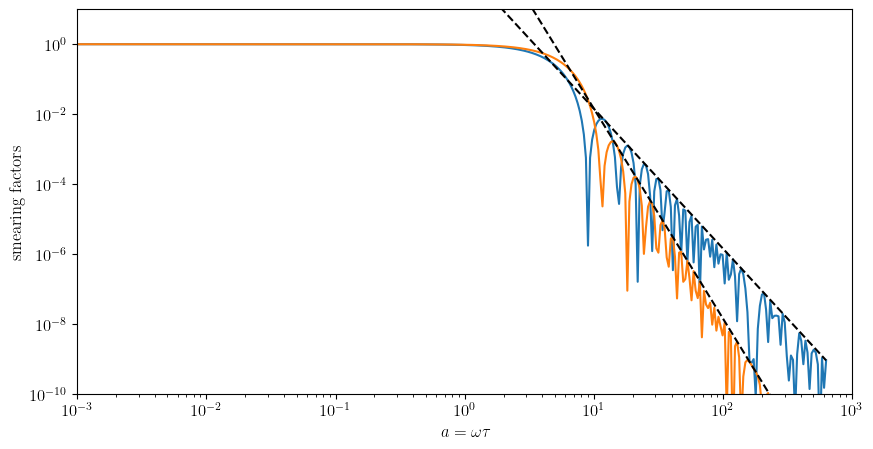

In [16]:
a = list_omega_out[1:] * t_int
list_smear_fac_mu = smear_fac_mu(a)
list_smear_fac_acc = smear_fac_acc(a)
fig,ax = plt.subplots(1,1,figsize=(10,5))
ax.plot(a,list_smear_fac_mu)
ax.plot(a,list_smear_fac_acc)
ax.plot(a,144 * a**-4,'--k')
ax.plot(a,14400 * a**-6,'--k')
ax.set_xscale('log'); ax.set_yscale('log');
ax.set_xlim(1e-3,1e3);
ax.set_ylim(1e-10,1e1);
ax.set_ylabel(r'smearing factors')
ax.set_xlabel(r'$a = \omega \tau$');

In [17]:
arr_C_ij_l_out = np.zeros((len(kappa_l),len(list_rho_s),len(list_r_s),2,2,len(list_omega_out)))
for i in range(len(kappa_l)):
    arr_C_ij_l_out[i] = f_sub * kappa_l[i] * arr_theta_E_l[:,:,None,None,None]**2 / list_omega_out * np.transpose(C_ij_integral(arr_gamma_l[:,:,None]/mu_tilde[i] * list_omega_out, zeta[i]),axes=(2,3,0,1,4))
arr_C_pq_l_out = np.einsum('aqj,abcpjm->abcpqm',inv_jacobian_fit, np.einsum('api,abcijm->abcpjm', inv_jacobian_fit, arr_C_ij_l_out)) # implement macrolensing of power spectrum

# added power spectra for all image pairs
N_images = len(kappa_l)
N_pairs = N_images * (N_images - 1) // 2
arr_Delta_C_pq_l_out = np.zeros((N_pairs,len(list_rho_s),len(list_r_s),2,2,len(list_omega_out))) # shape = N_pairs, len(list_rho_s), len(list_r_s), 2, 2,  len(list_omega_out)

count = 0
for i in range(N_images):
    for j in range(i+1,N_images):
        arr_Delta_C_pq_l_out[count] = arr_C_pq_l_out[i] + arr_C_pq_l_out[j]
        count+=1
        

# compute proper motion+acceleration covariance (factor of 2 in front is to count negative frequencies as well)
# arr_Delta_mu_pq_l_out = 2 * np.sum((list_omega_out[1:] - list_omega_out[:-1])/(2*np.pi) * list_omega_out[1:]**2 * arr_Delta_C_pq_l_out[:,:,:,:,:,1:],axis=-1)
# arr_Delta_acc_pq_l_out = 2 * np.sum((list_omega_out[1:] - list_omega_out[:-1])/(2*np.pi) * list_omega_out[1:]**4 * arr_Delta_C_pq_l_out[:,:,:,:,:,1:],axis=-1)
Delta_omega_out = list_omega_out[1:] - list_omega_out[:-1]
a = list_omega_out[1:] * t_int
list_smear_fac_mu = smear_fac_mu(a)
list_smear_fac_acc = smear_fac_acc(a)
arr_Delta_mu_pq_l_out = 2 * np.sum(list_smear_fac_mu * Delta_omega_out / (2*np.pi) * list_omega_out[1:]**2 * arr_Delta_C_pq_l_out[:,:,:,:,:,1:],axis=-1)
arr_Delta_acc_pq_l_out = 2 * np.sum(list_smear_fac_acc * Delta_omega_out / (2*np.pi) * list_omega_out[1:]**4 * arr_Delta_C_pq_l_out[:,:,:,:,:,1:],axis=-1)

arr_Delta_mu_pq_l_out = np.transpose(arr_Delta_mu_pq_l_out, axes=(1,2,0,3,4)) # reshape = len(list_rho_s), len(list_r_s), N_pairs, 2, 2
arr_Delta_acc_pq_l_out = np.transpose(arr_Delta_acc_pq_l_out, axes=(1,2,0,3,4)) # reshape = len(list_rho_s), len(list_r_s), N_pairs, 2, 2

arr_Delta_mu_mag_l_out = np.max(np.linalg.eigvals(arr_Delta_mu_pq_l_out),axis=-1) # magnitude of largest eigenvalue
arr_Delta_acc_mag_l_out = np.max(np.linalg.eigvals(arr_Delta_acc_pq_l_out),axis=-1) # magnitude of largest eigenvalue

arr_SNR_EPIC_mu = np.max(arr_Delta_mu_mag_l_out / sigma_mu_fit**2, axis=-1)
arr_SNR_EPIC_mu_tilde = np.max(arr_Delta_mu_mag_l_out / np.max(mu_tilde)**2, axis=-1)
arr_SNR_EPIC_acc = np.max(arr_Delta_acc_mag_l_out / sigma_acc_fit**2, axis=-1)

# effective noise for a differential image pair: instrumental floor plus the
# post-subtraction stellar residual of both images. Only image A's stellar budget has
# been studied (companion paper); adopt it as the per-image estimate for each bright image.
sigma2_acc_eff = sigma_acc_fit**2 + 2 * sigma2_acc_star_A
print('effective pair noise = %.3g muas^2/yr^4 (%.1f x instrumental)'
      % (sigma2_acc_eff/muasyy**2, sigma2_acc_eff/sigma_acc_fit**2))
arr_SNR_EPIC_acc_star = np.max(arr_Delta_acc_mag_l_out / sigma2_acc_eff, axis=-1)


effective pair noise = 2.74e-05 muas^2/yr^4 (11.4 x instrumental)


### Acceleration figure

In [18]:
list_rho_s.shape, list_r_s.shape, arr_Delta_acc_mag_l_out.shape, arr_M_l.shape

((176,), (150,), (176, 150, 6), (176, 150))

In [19]:
colors = sns.color_palette(xgfs_fancy6); colors

[(0.33725490196078434, 0.39215686274509803, 0.10196078431372549),
 (0.7529411764705882, 0.6862745098039216, 0.984313725490196),
 (0.9019607843137255, 0.6313725490196078, 0.4627450980392157),
 (0.0, 0.403921568627451, 0.5411764705882353),
 (0.596078431372549, 0.26666666666666666, 0.39215686274509803),
 (0.3686274509803922, 0.8, 0.6705882352941176),
 (0.803921568627451, 0.803921568627451, 0.803921568627451)]

rho_s = 1 M_Solar / pc^3
rho_s = 10 M_Solar / pc^3


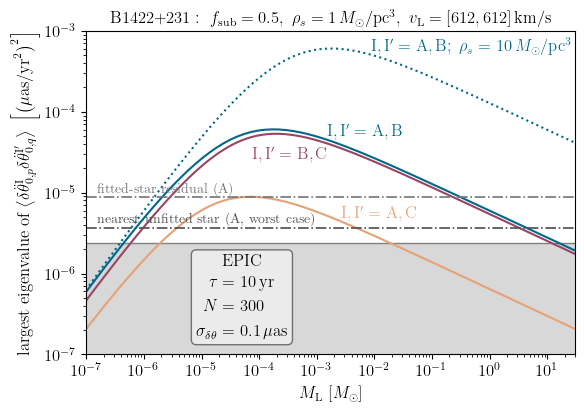

In [20]:
idx_rho_1 = 50; print('rho_s = %.2g M_Solar / pc^3' % (list_rho_s[idx_rho_1]/(M_Solar / pc**3)))
idx_rho_2 = 75; print('rho_s = %.2g M_Solar / pc^3' % (list_rho_s[idx_rho_2]/(M_Solar / pc**3)))


fig,ax = plt.subplots(1,1,figsize=(6.3,4.2))
#colors = sns.color_palette("husl", 4)

ax.fill_between(arr_M_l[idx_rho_1]/M_Solar,sigma_acc_EPIC**2 / muasyy**2,color=(0.5,0.5,0.5,1), facecolor=(0.5,0.5,0.5,0.3))

# stellar-microlensing benchmark levels (Sec. III C): worst-case bound from the
# nearest unfitted star, and the fitted-star subtraction residual. Both are smooth,
# single-perturber trends that can be certified against (chi^2 of the compact-source
# visibility model) and jointly fit, so they are not irreducible noise floors.

ax.plot(arr_M_l[idx_rho_1]/M_Solar, arr_Delta_acc_mag_l_out[idx_rho_1,:,0] / muasyy**2, color=colors[3], label=r'$\mathrm{I,I^\prime = A,B}$') # AB
ax.plot(arr_M_l[idx_rho_1]/M_Solar, arr_Delta_acc_mag_l_out[idx_rho_1,:,3] / muasyy**2, color=colors[4], label=r'$\mathrm{I,I^\prime = B,C}$') # BC
ax.plot(arr_M_l[idx_rho_1]/M_Solar, arr_Delta_acc_mag_l_out[idx_rho_1,:,1] / muasyy**2, color=colors[2], label=r'$\mathrm{I,I^\prime = A,C}$') # AC
ax.plot(arr_M_l[idx_rho_2]/M_Solar, arr_Delta_acc_mag_l_out[idx_rho_2,:,0] / muasyy**2, ls='dotted', color=colors[3], label=r'$\mathrm{I,I^\prime = A,B}$\\$\rho_s = 10\,M_\odot / \mathrm{pc}^3$') # AB
#ax.plot(arr_M_l[idx_rho_1]/M_Solar, arr_Delta_acc_mag_l_out[idx_rho_1,:,2] / muasyy**2) # AD
#ax.plot(arr_M_l[idx_rho_1]/M_Solar, arr_Delta_acc_mag_l_out[idx_rho_1,:,4] / muasyy**2) # BD
#ax.plot(arr_M_l[idx_rho_1]/M_Solar, arr_Delta_acc_mag_l_out[idx_rho_1,:,5] / muasyy**2) # CD
#ax.legend(loc='upper right', bbox_to_anchor=(1, 1),ncol=2,labelspacing=0.5, columnspacing=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-7,3e1)
ax.set_ylim(1e-7,1e-3)
ax.set_xlabel(r'$M_\mathrm{L}~[M_\odot]$');
ax.set_ylabel(r'largest eigenvalue of $\big \langle \delta \ddot \theta^\mathrm{I}_{0,p} \delta \ddot \theta^\mathrm{I^\prime}_{0,q} \big \rangle~\left[\left(\mathrm{\mu as / yr}^2\right)^2\right]$')

idx_lab_0 = 78
ax.text(arr_M_l[idx_rho_1,idx_lab_0]/M_Solar,arr_Delta_acc_mag_l_out[idx_rho_1,idx_lab_0,0]/muasyy**2,r'$\mathrm{I,I^\prime = A,B}$',color=colors[3],ha='left',va='bottom')
idx_lab_1 = 78
ax.text(arr_M_l[idx_rho_1,idx_lab_1]/M_Solar,0.9*arr_Delta_acc_mag_l_out[idx_rho_1,idx_lab_1,3]/muasyy**2,r'$\mathrm{I,I^\prime = B,C}$',color=colors[4],ha='right',va='top')
idx_lab_2 = 80
ax.text(arr_M_l[idx_rho_1,idx_lab_2]/M_Solar,arr_Delta_acc_mag_l_out[idx_rho_1,idx_lab_2,1]/muasyy**2,r'$\mathrm{I,I^\prime = A,C}$',color=colors[2],ha='left',va='bottom')
idx_lab_3 = 76
ax.text(arr_M_l[idx_rho_2,idx_lab_3]/M_Solar,arr_Delta_acc_mag_l_out[idx_rho_2,idx_lab_3,0]/muasyy**2,r'$\mathrm{I,I^\prime = A,B};~\rho_s = 10\,M_\odot / \mathrm{pc}^3$',color=colors[3],ha='left',va='bottom')

# stellar-microlensing residual levels at image A (Sec. III C), rescaled to this
# survey (theta_fit ~ 17 muas): worst-case unfitted star and fitted-star residual.
ax.axhline(sigma2_acc_fitted_A / muasyy**2, color=(0.45,0.45,0.45), lw=1.2, ls='dashdot')
ax.text(1.5e-7, 1.03*sigma2_acc_fitted_A/muasyy**2, r'fitted-star residual (A)',
        fontsize=10, color=(0.45,0.45,0.45), ha='left', va='bottom')
ax.axhline(sigma2_acc_unfitted_A / muasyy**2, color=(0.3,0.3,0.3), lw=1.2, ls='dashdot')
ax.text(1.5e-7, 1.03*sigma2_acc_unfitted_A/muasyy**2, r'nearest unfitted star (A, worst case)',
        fontsize=10, color=(0.3,0.3,0.3), ha='left', va='bottom')


ax.text(5e-5,1.7e-6,
        r'\begin{align*} \text{EPIC} \end{align*} \vspace{-3em} \begin{align*}\tau &= %.5g \,\mathrm{yr} \\ N &= %.5g \\ \sigma_{\delta \theta} &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((t_int/year),(N_obs),(sigma_delta_theta/muas)),
        ha='center',va='top',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5));

ax.set_title(r'$\mathrm{B1422{+}231}: ~f_\mathrm{sub} = %.1g, ~\rho_s = %.2g \,M_\odot/\mathrm{pc^3}, ~v_\mathrm{L} = [%.3g,%.3g] \,\mathrm{km/s}$'
              % (fraction_sub, (list_rho_s[idx_rho_1]/(M_Solar/pc**3)), (v_lens[0]/(km/second)), (v_lens[1]/(km/second))),
              fontsize=12);
fig.savefig('../figs/acc.pdf', bbox_inches='tight')

### Reference

\begin{align}
\rho_s = \frac{M_\mathrm{L}}{4\pi \sqrt{e} r_s^3}
\end{align}

In [21]:
list_r_s_ref = np.logspace(-4,1,6) * pc
list_M_ref = np.logspace(-10,5,100) * M_Solar
arr_rho_s_ref = np.asarray([list_M_ref / (4*np.pi*np.exp(1/2)*r_s**3) for r_s in list_r_s_ref])
int_rho_s_ref_1 = interp1d(list_M_ref, arr_rho_s_ref[0], kind='linear', bounds_error=False, fill_value='extrapolate')
int_rho_s_ref_2 = interp1d(list_M_ref, arr_rho_s_ref[1], kind='linear', bounds_error=False, fill_value='extrapolate')
int_rho_s_ref_3 = interp1d(list_M_ref, arr_rho_s_ref[2], kind='linear', bounds_error=False, fill_value='extrapolate')
int_rho_s_ref_4 = interp1d(list_M_ref, arr_rho_s_ref[3], kind='linear', bounds_error=False, fill_value='extrapolate')
int_rho_s_ref_5 = interp1d(list_M_ref, arr_rho_s_ref[4], kind='linear', bounds_error=False, fill_value='extrapolate')
int_rho_s_ref_6 = interp1d(list_M_ref, arr_rho_s_ref[5], kind='linear', bounds_error=False, fill_value='extrapolate')

### Plot

In [22]:
colors = sns.color_palette(xgfs_fancy6); colors

[(0.33725490196078434, 0.39215686274509803, 0.10196078431372549),
 (0.7529411764705882, 0.6862745098039216, 0.984313725490196),
 (0.9019607843137255, 0.6313725490196078, 0.4627450980392157),
 (0.0, 0.403921568627451, 0.5411764705882353),
 (0.596078431372549, 0.26666666666666666, 0.39215686274509803),
 (0.3686274509803922, 0.8, 0.6705882352941176),
 (0.803921568627451, 0.803921568627451, 0.803921568627451)]

/var/folders/4c/r0fv34l54990y0356vhxlw7c0000gn/T/ipykernel_2925/276836072.py:23: RuntimeWarning: divide by zero encountered in log10
  cs_SNR = ax.contour(arr_M_l/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC), colors=3*[colors[2]], linewidths=[4,2,1], levels=[0,2,4])


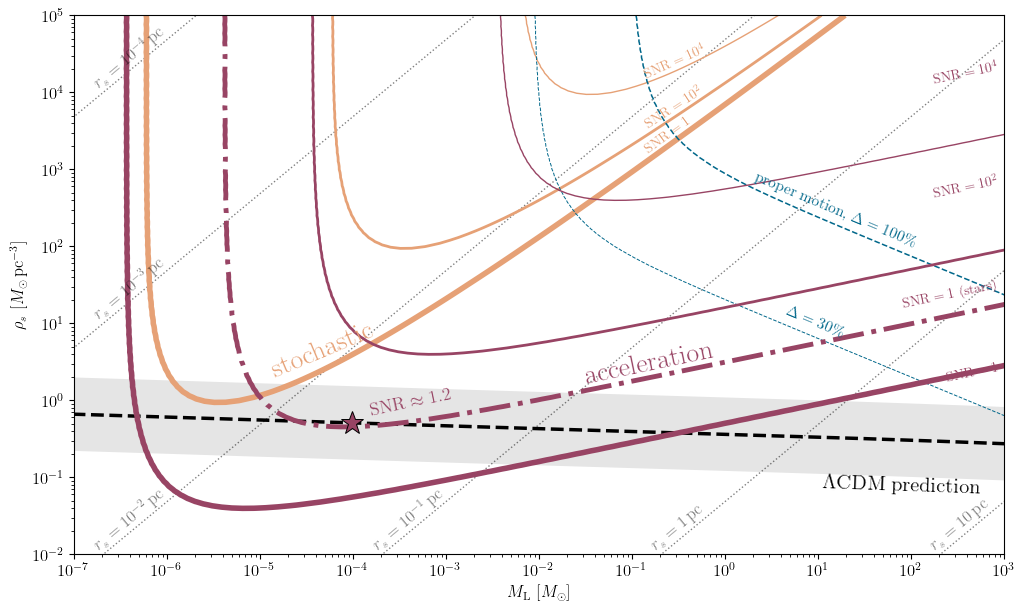

In [23]:
fig,ax = plt.subplots(1,1,figsize=(12,7))
rotation = 40; 
rotation_2 = np.arctan(np.tan(rotation*degree) / 4) / degree
rotation_3 = np.arctan(np.tan(rotation*degree) / 2) / degree
#ax.scatter(arr_M_l/M_Solar, arr_rho_s/(M_Solar/pc**3), c=np.log10(arr_r_s/pc), cmap='viridis', s=2);

# LambdaCDM prediction: rho_s(M) relation with a factor-3 band for the concentration
# scatter and definitional spread; the dashed line is the fiducial relation.
ax.fill_between(list_M_s_pred/M_Solar, list_rho_s_pred/(M_Solar/pc**3)/3, 3*list_rho_s_pred/(M_Solar/pc**3),
                color=(0,0,0,0.10), lw=0)
ax.plot(list_M_s_pred/M_Solar, list_rho_s_pred/(M_Solar/pc**3), 'k--', lw=2.5)
ax.text(1.1e1, 0.115, r'$\Lambda$CDM prediction', color='k', fontsize=15, ha='left', va='top', rotation=-2)

# peak acceleration-channel SNR along the CDM relation (impact_numbers.py):
# 1.2 with the worst-case stellar residual noise; 13 for certified-clean epochs
M_peak_CDM = 9.7e-5
rho_peak_CDM = np.interp(np.log10(M_peak_CDM), np.log10(list_M_s_pred/M_Solar), list_rho_s_pred/(M_Solar/pc**3))
ax.plot([M_peak_CDM],[rho_peak_CDM], marker='*', ms=17, color=colors[4], mec='k', mew=0.7, zorder=5)
ax.text(1.5*M_peak_CDM, 1.12*rho_peak_CDM, r'$\mathrm{SNR}\approx1.2$', rotation=rotation_2, color=colors[4], fontsize=13, ha='left', va='bottom')

for i in range(len(list_r_s_ref)):
    ax.plot(list_M_ref/M_Solar, arr_rho_s_ref[i]/(M_Solar/pc**3), color=(0,0,0,0.5), ls='dotted', lw=1)
cs_SNR = ax.contour(arr_M_l/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC), colors=3*[colors[2]], linewidths=[4,2,1], levels=[0,2,4])
cs_SNR_mu = ax.contour(arr_M_l/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC_mu_tilde), linestyles='dashed',colors=2*[colors[3]],linewidths=[0.7,1.1], levels=[np.log10(0.3**2),0])
# instrument-limited (certifiably star-free) acceleration reach, SNR = 1, 10^2, 10^4 (solid),
# matching the instrument-limited stochastic family and the matter_power figure
cs_SNR_acc = ax.contour(arr_M_l/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC_acc), colors=3*[colors[4]], linewidths=[4,2,1], levels=[0,2,4])
# worst-case post-subtraction stellar-microlensing-limited acceleration reach, SNR = 1 (thick dot-dashed)
cs_SNR_acc_star = ax.contour(arr_M_l/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC_acc_star), colors=[colors[4]], linestyles='dashdot', linewidths=[3.5], levels=[0])
#cs_SNR_tilde = ax.contour(arr_M_l/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC_tilde), cmap='magma', linewidths=2, levels=range(0,7))
#ax.clabel(cs_SNR_mu, inline=True, fontsize=20) 

xlim = (1e-7,1e3); ax.set_xlim(xlim);
ylim = (1e-2,1e5); ax.set_ylim(ylim);
ax.set_xscale('log');
ax.set_yscale('log');
ax.set_xlabel(r'$M_\mathrm{L}~[M_\odot]$');
ax.set_ylabel(r'$\rho_s~[M_\odot \, \mathrm{pc}^{-3}]$');
ax.set_xticks(np.logspace(np.log10(xlim[0]),np.log10(xlim[1]),1+int(np.log10(xlim[1]/xlim[0]))),minor=False);
ax.set_xticks(np.outer(np.logspace(np.log10(xlim[0]),np.log10(xlim[1])-1,int(np.log10(xlim[1]/xlim[0]))),range(1,10)).flatten(),minor=True);
ax.text(1.5e-7,1.4*int_rho_s_ref_1(1.5e-7*M_Solar) / (M_Solar/pc**3),r'$r_s = 10^{-4} \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)
ax.text(1.5e-7,1.4*int_rho_s_ref_2(1.5e-7*M_Solar) / (M_Solar/pc**3),r'$r_s = 10^{-3} \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)
ax.text(1.5e-7,1.4*int_rho_s_ref_3(1.5e-7*M_Solar) / (M_Solar/pc**3),r'$r_s = 10^{-2} \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)
ax.text(1.5e-4,1.4*int_rho_s_ref_4(1.5e-4*M_Solar) / (M_Solar/pc**3),r'$r_s = 10^{-1} \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)
ax.text(1.5e-1,1.4*int_rho_s_ref_5(1.5e-1*M_Solar) / (M_Solar/pc**3),r'$r_s = 1 \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)
ax.text(1.5e2,1.4*int_rho_s_ref_6(1.5e2*M_Solar) / (M_Solar/pc**3),r'$r_s = 10 \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)

ax.text(1.2e-5,1.7e0,"stochastic",color=colors[2],fontsize=20,ha='left',va='bottom',rotation=rotation_3)
ax.text(1.3e-1,1.5e3,r"$\mathrm{SNR} = 1$",color=colors[2],fontsize=10,ha='left',va='bottom',rotation=36)
ax.text(1.3e-1,3.2e3,r"$\mathrm{SNR} = 10^2$",color=colors[2],fontsize=10,ha='left',va='bottom',rotation=33)
ax.text(1.3e-1,1.4e4,r"$\mathrm{SNR} = 10^4$",color=colors[2],fontsize=10,ha='left',va='bottom',rotation=24)

ax.text(1.2e2,9e1,r"proper motion, $\Delta = 100\%$",color=colors[3],va='bottom',ha='right',fontsize=11,rotation=-rotation_3)
ax.text(2e1,6e0,r"$\Delta = 30\%$",color=colors[3],fontsize=11,va='bottom',ha='right',rotation=-rotation_3)


ax.text(3e-2,1.4e0,"acceleration",color=colors[4],fontsize=20,rotation=rotation_2,va='bottom',ha='left')
ax.text(9e2,1.6e0,r"$\mathrm{SNR} = 1$",color=colors[4],fontsize=10,ha='right',va='bottom',rotation=rotation_2)
ax.text(9e2,9*1.6e0,r"$\mathrm{SNR} = 1$ (stars)",color=colors[4],fontsize=10,ha='right',va='bottom',rotation=rotation_2)
ax.text(9e2,4e2,r"$\mathrm{SNR} = 10^2$",color=colors[4],fontsize=10,ha='right',va='bottom',rotation=rotation_2)
ax.text(9e2,1.2e4,r"$\mathrm{SNR} = 10^4$",color=colors[4],fontsize=10,ha='right',va='bottom',rotation=rotation_2);

fig.savefig('../figs/SNR.pdf', bbox_inches='tight')

# Part II --- Cluster lens: SDSS J1029+2623

Cluster-lens analogue of Part I: a three-image quasar at $z_\mathrm{S} = 2.1992$
behind a galaxy *cluster* at $z_\mathrm{L} = 0.588$ (image separation $22.5''$),
with the convergence/shear at the images taken from the Acebron+2022
reconstruction (`params_J1029_2623.py`). Produces the direct analogues of the
Part I figures, `figs/CtildeC-J1029.pdf` (stochastic PSD, cf. `CtildeA.pdf`) and
`figs/acc-J1029.pdf` (differential acceleration, cf. `acc.pdf`).

Three things differ from the galaxy lens:

1. **Kinematics.** The effective lens velocity is the cluster bulk motion
   (474 km/s) plus a *moving-clump* member-halo term ($f_\mathrm{gal} = 0.2$ of
   the local deflection gradient orbiting at $\sigma_v = 1000$ km/s), giving
   $v_\mathrm{eff} \approx 552$ km/s; the microhalos' own dispersion enters the
   sweep rate unmagnified.
2. **Stellar background.** $\kappa_* \approx 0.003$ (vs $\approx 0.05$ for the
   galaxy lens): the images form in the DM-dominated cluster outskirts, so the
   rare stellar perturbers are single, identifiable trends rather than a
   stochastic background.
3. **Finite source.** J1029+2623 is faint, so the optical accretion-disk size
   matters: the magnified source size $\theta^\mathrm{I}_\mathrm{src}$ acts as a
   high-pass filter in halo mass, implemented by `C_ij_integral_src`
   (quadrature $x_k \to \sqrt{x_k^2 + x_\mathrm{src}^2}$).

The `from params_J1029_2623 import *` below rebinds the system-level names set by
Part I; see the run-order note at the top.

In [24]:
from preamble import *
from natural_units_GeV import *
from macro_lens_functions import *
from sensitivity_functions import *
# NOTE: this star-import deliberately rebinds the system-level names from the
# galaxy lens (d_lens, z_lens, kappa_fit, inv_jacobian_fit, mag_fit, eigvals_fit,
# labels, kappa_star, M_star, theta_E_star, mu_int_drift, v_lens_fid, ...) to
# their SDSS J1029+2623 values. Everything below refers to the cluster lens.
from params_J1029_2623 import *

xgfs_fancy6 = 255**-1 * np.asarray([(86, 100, 26), (192, 175, 251), (230, 161, 118),
                                    (0, 103, 138), (152, 68, 100), (94, 204, 171), (205, 205, 205)])

In [25]:
# ---------------------------------------------------------------------------
# survey + lens-velocity configuration
# ---------------------------------------------------------------------------
v_obs = np.asarray([0, 0]) * km / second
v_lens = v_lens_fid                       # EFFECTIVE fiducial |v_L| ~ 552 km/s (macro-magnified):
                                          # bulk 474 (+) moving-clump member-halo term (see params)
v_source = np.asarray([0, 0]) * km / second

# fiducial differential-astrometry survey. J1029 is too faint for intensity
# interferometry (EPIC); we take a fiducial optical imager/interferometer
# light-centroiding precision, conservative relative to EPIC's 0.1 muas.
t_int = 10 * year
sigma_delta_theta = 1.0 * muas
N_obs = 300

sigma_mu_fit = 2 * np.sqrt(3) * sigma_delta_theta / np.sqrt(N_obs * t_int**2)
sigma_acc_fit = 12 * np.sqrt(5) * sigma_delta_theta / np.sqrt(N_obs * t_int**4)

fraction_sub = 0.5
kappa_l = kappa_fit * fraction_sub        # DM substructure convergence at images

vec_mu_source = mu_rel(v_obs, v_lens, v_source, z_lens, z_source, d_lens, d_source, d_lens_source)
vec_mu_tilde = np.tensordot(inv_jacobian_fit, vec_mu_source, axes=1)   # magnified image proper motion (bulk)
mu_tilde_bulk = np.linalg.norm(vec_mu_tilde, axis=1)
# sweep rate across a subhalo's deflection field: d/dt[theta^I - theta_h] = B mu_bulk - mu_h,int.
# The subhalo's own orbital motion enters UNMAGNIFIED (kinematics fix; see params):
mu_tilde = np.sqrt(mu_tilde_bulk**2 + mu_int_drift**2)
zeta = np.arctan2(vec_mu_tilde[:, 1], vec_mu_tilde[:, 0])

In [26]:
# ---------------------------------------------------------------------------
# physics summary (printed)
# ---------------------------------------------------------------------------
print("="*72)
print("SDSS J1029+2623  (cluster lens):  z_L=%.3f, z_S=%.4f" % (z_lens, z_source))
print("="*72)
print("magnifications mu          =", np.round(mag_fit, 1))
print("mu_tilde (bulk) [muas/yr]  =", np.round(mu_tilde_bulk/muasy, 2))
print("internal drift [muas/yr]   = %.3f (unmagnified, sqrt(2)*sigma_v, sigma_v=%.0f km/s 1D)"
      % (mu_int_drift/muasy, sigma_v_cluster/(km/second)))
print("mu_sweep [muas/yr]         =", np.round(mu_tilde/muasy, 2))
print("v_eff = D_L*mu_sweep [km/s]=", np.round(mu_tilde*d_lens/(km/second), 0))
print("kappa_*                    = %.3f  (vs ~0.05 for galaxy lens B1422)" % kappa_star)
N_fit = kappa_star * Sigma_crit_val / M_star * np.pi * (10*muas)**2 * d_lens**2
print("N_fit (<10 muas)           = %.2f stars  ->  stellar background negligible" % N_fit)

print("\noptimal halo (gamma_L ~ mu_tilde * tau, tau=%.0f yr):" % (t_int/year))
for i in range(3):
    gL = mu_tilde[i]*t_int; rL = gL*d_lens
    M1 = 4*np.pi*np.exp(0.5)*(1.0*M_Solar/pc**3)*rL**3
    M10 = 4*np.pi*np.exp(0.5)*(10.0*M_Solar/pc**3)*rL**3
    print("  image %s: gamma_L=%5.1f muas, r_L=%.3f pc, M_L=%.1e--%.1e M_sun (rho_s=1--10)"
          % (labels[i], gL/muas, rL/pc, M1/M_Solar, M10/M_Solar))

gamma_L_opt = mu_tilde.max()*t_int   # optimal substructure angular size (stochastic channel)
print("\nfinite-source filter: halos with gamma_L < theta_src^I (magnified source) are suppressed.")
print("  optical disk R=%.1e cm: theta_src^I(B,C) ~ %.1f muas" % (R_source/cm, theta_source_I[2]/muas))
for jc in range(len(R_source_radio)):
    print("  radio core  R=%.2f pc:  theta_src^I(B,C) ~ %5.0f muas"
          % (R_source_radio[jc]/pc, theta_source_radio_I[2, jc]/muas))

SDSS J1029+2623  (cluster lens):  z_L=0.588, z_S=2.1992
magnifications mu          = [  6.6  21.6 -21.9]
mu_tilde (bulk) [muas/yr]  = [0.07 1.13 1.08]
internal drift [muas/yr]   = 0.138 (unmagnified, sqrt(2)*sigma_v, sigma_v=1000 km/s 1D)
mu_sweep [muas/yr]         = [0.16 1.13 1.09]
v_eff = D_L*mu_sweep [km/s]= [1008. 7346. 7039.]
kappa_*                    = 0.003  (vs ~0.05 for galaxy lens B1422)
N_fit (<10 muas)           = 0.28 stars  ->  stellar background negligible

optimal halo (gamma_L ~ mu_tilde * tau, tau=10 yr):
  image A: gamma_L=  1.6 muas, r_L=0.010 pc, M_L=2.3e-05--2.3e-04 M_sun (rho_s=1--10)
  image B: gamma_L= 11.3 muas, r_L=0.075 pc, M_L=8.8e-03--8.8e-02 M_sun (rho_s=1--10)
  image C: gamma_L= 10.9 muas, r_L=0.072 pc, M_L=7.7e-03--7.7e-02 M_sun (rho_s=1--10)

finite-source filter: halos with gamma_L < theta_src^I (magnified source) are suppressed.
  optical disk R=1.5e+15 cm: theta_src^I(B,C) ~ 1.3 muas
  radio core  R=0.01 pc:  theta_src^I(B,C) ~    27 muas
  radio

## Stochastic PSD $\widetilde{C}_{pq}(\omega)$ for the bright image C  →  `figs/CtildeC-J1029.pdf`

Direct analogue of the galaxy-lens `figs/CtildeA.pdf` above (Part I), now including the optical finite-source form factor.

saved ../figs/CtildeC-J1029.pdf


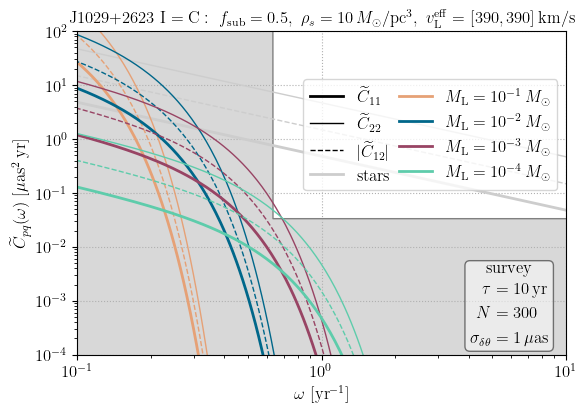

In [27]:
# ---------------------------------------------------------------------------
# Figure 1: stochastic PSD  C_pq(omega)  for the bright image (Eq. C)
# ---------------------------------------------------------------------------
vec_omega = np.logspace(-1.3, 1.3, 400) * year**-1
vec_M_l = np.asarray([1e-1, 1e-2, 1e-3, 1e-4]) * M_Solar
rho_s = 1e1 * M_Solar * pc**-3

arr_C_ij_l = np.zeros((3, len(vec_M_l), 2, 2, len(vec_omega)))
for j, M_l in enumerate(vec_M_l):
    r_s = (M_l/(rho_s*(4*np.pi*np.exp(1/2))))**(1/3)
    gamma_l = r_s/d_lens
    theta_E_l = theta_E(M_l, d_lens, d_source, d_lens_source)
    for i in range(3):
        x_k = gamma_l/mu_tilde[i] * vec_omega
        x_src = theta_source_I[i]/mu_tilde[i] * vec_omega   # optical finite-source cutoff
        arr_C_ij_l[i, j] = kappa_l[i] * theta_E_l**2 / vec_omega * C_ij_integral_src(x_k, x_src, zeta[i])
arr_C_pq_l = np.einsum('aqj,abpjm->abpqm', inv_jacobian_fit,
                       np.einsum('api,abijm->abpjm', inv_jacobian_fit, arr_C_ij_l))

# stellar PSD (naive) and instrument noise
vec_C_star = kappa_star * theta_E_star**2 / vec_omega * np.pi
arr_C_ij_star = np.asarray([[vec_C_star, np.zeros_like(vec_C_star)], [np.zeros_like(vec_C_star), vec_C_star]])
arr_C_pq_star = np.einsum('aqj,apjm->apqm', inv_jacobian_fit, np.einsum('api,ijm->apjm', inv_jacobian_fit, arr_C_ij_star))
vec_C_EPIC = C_EPIC(vec_omega, t_int=t_int, N_obs=N_obs, sigma_delta_theta=sigma_delta_theta)

idx_l = 2   # bright image C (mu ~ -22)
fig, ax = plt.subplots(1, 1, figsize=(6.3, 4.2))
colors = [sns.color_palette(xgfs_fancy6)[i] for i in [2, 3, 4, 5, 6]]
ax.plot([], [], color='k', lw=2, label=r'$\widetilde{C}_{11}$')
ax.plot([], [], color='k', lw=1, label=r'$\widetilde{C}_{22}$')
ax.plot([], [], color='k', lw=1, ls='dashed', label=r'$|\widetilde{C}_{12}|$')
i = idx_l
ax.plot(vec_omega/year**-1, arr_C_pq_star[i, 0, 0]/(muas**2*year), color=colors[4], lw=2, label='stars')
ax.plot(vec_omega/year**-1, arr_C_pq_star[i, 1, 1]/(muas**2*year), color=colors[4], lw=1)
ax.plot(vec_omega/year**-1, np.abs(arr_C_pq_star[i, 0, 1])/(muas**2*year), color=colors[4], lw=1, ls='dashed')
for j, M_l in enumerate(vec_M_l):
    ax.plot(vec_omega/year**-1, arr_C_pq_l[i, j, 0, 0]/(muas**2*year), color=colors[j], lw=2,
            label=r'$M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))
    ax.plot(vec_omega/year**-1, arr_C_pq_l[i, j, 1, 1]/(muas**2*year), color=colors[j], lw=1)
    ax.plot(vec_omega/year**-1, np.abs(arr_C_pq_l[i, j, 0, 1])/(muas**2*year), color=colors[j], lw=1, ls='dashed')
ax.fill_between(vec_omega/year**-1, vec_C_EPIC/(muas**2*year), color=(0.5, 0.5, 0.5, 1), facecolor=(0.5, 0.5, 0.5, 0.3), lw=1)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\omega~ [\mathrm{yr}^{-1}$]')
ax.set_ylabel(r'$\widetilde{C}_{pq}(\omega) ~[\mathrm{\mu as^2 \, yr}]$')
ax.grid(ls='dotted'); ax.set_xlim(1e-1, 1e1); ax.set_ylim(1e-4, 1e2)
ax.legend(loc='center right', bbox_to_anchor=(1, 0.68), ncol=2, labelspacing=0.5, columnspacing=0.5)
ax.text(0.85e1, 8e-4,
        r'\begin{align*} \text{survey} \end{align*} \vspace{-3em} \begin{align*}\tau &= %.5g \,\mathrm{yr} \\ N &= %.5g \\ \sigma_{\delta \theta} &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((t_int/year), (N_obs), (sigma_delta_theta/muas)),
        ha='right', va='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax.set_title(r'$\mathrm{J1029{+}2623}~\text{I}=\mathrm{%s}: ~f_\mathrm{sub} = %.1g, ~\rho_s = %.2g \,M_\odot/\mathrm{pc^3}, ~v_\mathrm{L}^\mathrm{eff} = [%.3g,%.3g] \,\mathrm{km/s}$'
             % (labels[idx_l], fraction_sub, (rho_s/(M_Solar/pc**3)), (v_lens[0]/(km/second)), (v_lens[1]/(km/second))),
             fontsize=12)
fig.savefig('../figs/CtildeC-J1029.pdf', bbox_inches='tight')
print("saved ../figs/CtildeC-J1029.pdf")
plt.show()

## Differential acceleration covariance vs $M_\mathrm{L}$  →  `figs/acc-J1029.pdf`

Direct analogue of the galaxy-lens `figs/acc.pdf` above (Part I). The computation lives in the next cell and the plotting (labels, ranges) in the one after it, so the figure can be re-tuned without recomputing.

In [28]:
# ---------------------------------------------------------------------------
# differential acceleration covariance vs M_L (Eq. observable_2) -- COMPUTATION
# ---------------------------------------------------------------------------
def smear_fac_acc(a):
    return np.heaviside(-a + 1e-2, 0) + np.heaviside(a - 1e-2, 0) * 14400 * (6*a*np.cos(a/2) + (-12 + a**2)*np.sin(a/2))**2 / a**10

list_r_s = 10**np.arange(-4.5, 1.5, 0.04) * pc
list_omega_out = np.logspace(-6, 2, int(5e2)) * 2*np.pi/t_int
Delta_omega_out = list_omega_out[1:] - list_omega_out[:-1]
smear_acc = smear_fac_acc(list_omega_out[1:]*t_int)

def acc_cov_pairs(rho_s_val, theta_src_I=np.zeros(3)):
    '''largest-eigenvalue differential acceleration covariance for the 3 image pairs.

    kappa_l already includes fraction_sub (kappa_l = fraction_sub*kappa_fit); a
    former f_sub argument double-counted it (fixed 2026-07-18).
    theta_src_I : per-image magnified source size (0 = point source). Enters the
    form factor in quadrature with the halo size via C_ij_integral_src.
    '''
    list_M_l = 4*np.pi*np.exp(0.5)*rho_s_val*list_r_s**3
    list_gamma_l = list_r_s/d_lens
    list_theta_E_l = theta_E(list_M_l, d_lens, d_source, d_lens_source)
    arr_C_ij = np.zeros((3, len(list_r_s), 2, 2, len(list_omega_out)))
    for i in range(3):
        x_k = list_gamma_l[:, None]/mu_tilde[i]*list_omega_out
        x_src = theta_src_I[i]/mu_tilde[i]*list_omega_out
        arr_C_ij[i] = kappa_l[i]*list_theta_E_l[:, None, None, None]**2/list_omega_out \
            * np.transpose(C_ij_integral_src(x_k, x_src, zeta[i]), axes=(2, 0, 1, 3))
    arr_C_pq = np.einsum('aqj,abpjm->abpqm', inv_jacobian_fit, np.einsum('api,abijm->abpjm', inv_jacobian_fit, arr_C_ij))
    pairs = [(0, 1), (0, 2), (1, 2)]  # AB, AC, BC
    out = np.zeros((len(pairs), len(list_r_s), 2, 2))
    for p, (i, j) in enumerate(pairs):
        dC = arr_C_pq[i] + arr_C_pq[j]      # (r_s, 2, 2, omega)
        out[p] = 2*np.sum(smear_acc*Delta_omega_out/(2*np.pi)*list_omega_out[1:]**4*dC[:, :, :, 1:], axis=-1)
    eig = np.max(np.linalg.eigvals(np.transpose(out, (0, 1, 2, 3))), axis=-1)
    M_l = list_M_l
    return M_l, np.real(eig)   # (pair, r_s)

# Consolidated acceleration figure: the OPTICAL differential-acceleration covariance
# vs M_L, at the two CDM-plausible scale densities rho_s = 1, 10 M_sun/pc^3.
M_l_1, acc_1 = acc_cov_pairs(1.0*M_Solar/pc**3, theta_src_I=theta_source_I)
M_l_10, acc_10 = acc_cov_pairs(10.0*M_Solar/pc**3, theta_src_I=theta_source_I)
sigma_acc_survey = np.sqrt(720 * sigma_delta_theta**2 / (t_int**4 * N_obs))
pAB, pAC, pBC = 0, 1, 2

print("\ndetection headroom (optical, sigma_dth=%.2g muas; floor = %.2e (muas/yr^2)^2):"
      % (sigma_delta_theta/muas, sigma_acc_survey**2/muasyy**2))
for rho, (Ml, acc) in [(1, (M_l_1, acc_1)), (10, (M_l_10, acc_10))]:
    for p, nm in [(pAB, 'A,B'), (pAC, 'A,C'), (pBC, 'B,C')]:
        pk = acc[p].max(); Mpk = Ml[np.argmax(acc[p])]
        det = Ml[acc[p] > sigma_acc_survey**2]/M_Solar
        rng = "%.1e--%.1e" % (det[0], det[-1]) if det.size else "none"
        print("  rho_s=%2d %s: peak=%.2e at M_L=%.2g, SNR^2_peak=%4.1f, detect M_L=%s M_sun"
              % (rho, nm, pk/muasyy**2, Mpk/M_Solar, pk/sigma_acc_survey**2, rng))


detection headroom (optical, sigma_dth=1 muas; floor = 2.40e-04 (muas/yr^2)^2):
  rho_s= 1 A,B: peak=1.66e-04 at M_L=0.0005, SNR^2_peak= 0.7, detect M_L=none M_sun
  rho_s= 1 A,C: peak=1.61e-04 at M_L=0.00038, SNR^2_peak= 0.7, detect M_L=none M_sun
  rho_s= 1 B,C: peak=3.26e-04 at M_L=0.0005, SNR^2_peak= 1.4, detect M_L=9.5e-05--3.4e-03 M_sun
  rho_s=10 A,B: peak=1.66e-03 at M_L=0.005, SNR^2_peak= 6.9, detect M_L=6.0e-05--6.6e+00 M_sun
  rho_s=10 A,C: peak=1.61e-03 at M_L=0.0038, SNR^2_peak= 6.7, detect M_L=6.0e-05--6.6e+00 M_sun
  rho_s=10 B,C: peak=3.26e-03 at M_L=0.005, SNR^2_peak=13.6, detect M_L=2.6e-05--6.0e+01 M_sun


median nearest star at 15.7 muas -> worst-case acc^2 = 2.16e-04 (muas/yr^2)^2


saved ../figs/acc-J1029.pdf
sigma_acc(survey, optical) = 0.015 muas/yr^2


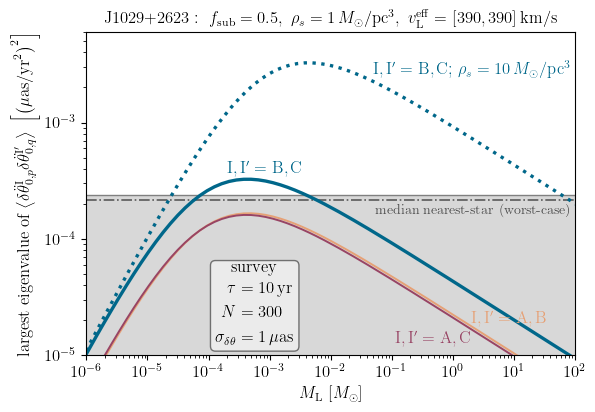

In [29]:
# ---------------------------------------------------------------------------
# differential acceleration covariance vs M_L -- PLOT (labels/ranges tuned)
# ---------------------------------------------------------------------------
# All label positions are given directly in data coordinates (M_L in M_sun,
# covariance in (muas/yr^2)^2) so they are easy to nudge interactively.
fig, ax = plt.subplots(1, 1, figsize=(6.3, 4.2))
colors = sns.color_palette(xgfs_fancy6)

# --- noise floor (survey) + worst-case identifiable single-star acceleration ---
ax.fill_between(M_l_1/M_Solar, sigma_acc_survey**2/muasyy**2,
                color=(0.5, 0.5, 0.5, 1), facecolor=(0.5, 0.5, 0.5, 0.3))
# worst-case acceleration from the median nearest star (Sec. III D): a single,
# identifiable, few-parameter perturber -- half of all images are cleaner than
# this for the entire campaign, and the trend can be jointly fit and removed.
n_star_dens = kappa_star * Sigma_crit_val / M_star
theta_near_med = np.sqrt(np.log(2)/(np.pi*n_star_dens)) / d_lens
B_max_C = np.max(np.abs(eigvals_fit[2]))
acc_star_wc = 2*B_max_C*theta_E_star**2*mu_tilde[2]**2/theta_near_med**3
print("median nearest star at %.1f muas -> worst-case acc^2 = %.2e (muas/yr^2)^2"
      % (theta_near_med/muas, acc_star_wc**2/muasyy**2))
ax.axhline(acc_star_wc**2/muasyy**2, color=(0.35, 0.35, 0.35), lw=1.2, ls='dashdot')

# --- signal curves ---
# rho_s = 1 M_sun/pc^3 (solid): the three image pairs; B,C is the bright pair
ax.plot(M_l_1/M_Solar, acc_1[pAB]/muasyy**2, color=colors[2], lw=1.4)
ax.plot(M_l_1/M_Solar, acc_1[pAC]/muasyy**2, color=colors[4], lw=1.4)
ax.plot(M_l_1/M_Solar, acc_1[pBC]/muasyy**2, color=colors[3], lw=2.4)
# rho_s = 10 M_sun/pc^3 (dotted): the bright B,C pair -> strongest detection prospect
ax.plot(M_l_10/M_Solar, acc_10[pBC]/muasyy**2, color=colors[3], lw=2.4, ls='dotted')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(1e-6, 1e2)
ax.set_ylim(1e-5, 6e-3)      # tightened range: bottom just below the curve tails
                             # (~5e-6), top just above the rho_s=10 dotted peak (3.3e-3)
ax.set_xlabel(r'$M_\mathrm{L}~[M_\odot]$')
ax.set_ylabel(r'largest eigenvalue of $\big \langle \delta \ddot \theta^\mathrm{I}_{0,p} \delta \ddot \theta^\mathrm{I^\prime}_{0,q} \big \rangle~\left[\left(\mathrm{\mu as / yr}^2\right)^2\right]$')

# --- curve labels (data coords; nudge freely) --------------------------------
# B,C  rho_s=10 (dotted): above the descending branch, clear upper-right band
ax.text(5e-2, 2.4e-3, r'$\mathrm{I,I^\prime = B,C}$; '+r'$\rho_s = 10\,M_\odot / \mathrm{pc}^3$',
        color=colors[3], ha='left', va='bottom')
# B,C  rho_s=1 (solid): floating in the gap between the solid B,C and dotted curves
ax.text(2e-4, 4.0e-4, r'$\mathrm{I,I^\prime = B,C}$', color=colors[3], ha='left', va='center')
# A,C: below the (near-degenerate) A,B/A,C track on the rising left branch
ax.text(2, 1.6e-5, r'$\mathrm{I,I^\prime = A,C}$', color=colors[4], ha='right', va='top')
# A,B: below the same track on the descending right branch (far from A,C)
ax.text(2, 1.75e-5, r'$\mathrm{I,I^\prime = A,B}$', color=colors[2], ha='left', va='bottom')

# --- survey box (upper-left corner) ---
#ax.text(1.3e-6, 5.3e-3,
ax.text(1.3e-4, 1.2e-5,
        r'\begin{align*} \text{survey} \end{align*} \vspace{-3em} \begin{align*}\tau &= %.5g \,\mathrm{yr} \\ N &= %.5g \\ \sigma_{\delta \theta} &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((t_int/year), (N_obs), (sigma_delta_theta/muas)),
        ha='left', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# --- horizontal-line labels (anchored at opposite ends so they never collide) ---
#ax.text(1e-1, 2.5e-4, r'noise floor', fontsize=8.5, ha='left', va='bottom', color=(0.3, 0.3, 0.3))
ax.text(9e1, 2.0e-4, r'median nearest-star (worst-case)',
        fontsize=10, color=(0.3, 0.3, 0.3), ha='right', va='top')

ax.set_title(r'$\mathrm{J1029{+}2623}: ~f_\mathrm{sub} = %.1g, ~\rho_s = 1\,M_\odot/\mathrm{pc^3}, ~v_\mathrm{L}^\mathrm{eff} = [%.3g,%.3g] \,\mathrm{km/s}$'
             % (fraction_sub, (v_lens[0]/(km/second)), (v_lens[1]/(km/second))), fontsize=12)
fig.savefig('../figs/acc-J1029.pdf', bbox_inches='tight')
print("saved ../figs/acc-J1029.pdf")
print("sigma_acc(survey, optical) = %.2g muas/yr^2" % (sigma_acc_survey/muasyy))
plt.show()

## Finite-source + VLBI-radio study (printed diagnostics only)

The radio channel does not clear its noise floor for fiducial VLBI precision, so it
is reported here (feeding the numbers quoted in the text) but omitted from the
consolidated figure.

In [30]:
# ---------------------------------------------------------------------------
# Finite-source + VLBI-radio study (printed diagnostics only; no longer plotted).
# ---------------------------------------------------------------------------
rho_acc = 1.0*M_Solar/pc**3
_,  acc_point = acc_cov_pairs(rho_acc, theta_src_I=np.zeros(3))
_,  acc_opt   = acc_cov_pairs(rho_acc, theta_src_I=theta_source_I)
_,  acc_r001  = acc_cov_pairs(rho_acc, theta_src_I=theta_source_radio_I[:, 0])
_,  acc_r01   = acc_cov_pairs(rho_acc, theta_src_I=theta_source_radio_I[:, 1])
M_l_a, acc_r1 = acc_cov_pairs(rho_acc, theta_src_I=theta_source_radio_I[:, 2])

print("\nfinite-source effect on the B,C acceleration peak (rho_s=1):")
for name, acc in [("point ", acc_point), ("optical", acc_opt), ("radio 0.01pc", acc_r001),
                  ("radio 0.1pc ", acc_r01), ("radio 1pc  ", acc_r1)]:
    pk = acc[pBC].max(); Mpk = M_l_a[np.argmax(acc[pBC])]
    print("  %-12s peak = %.2e (muas/yr^2)^2 at M_L = %.2g M_sun" % (name, pk/muasyy**2, Mpk/M_Solar))

sigma_acc_VLBI = np.sqrt(720 * sigma_delta_theta_VLBI**2 / (t_int**4 * N_obs))
sigma_acc_VLBI_future = np.sqrt(720 * sigma_delta_theta_VLBI_future**2 / (t_int**4 * N_obs))
# VLBI precision required for SNR=1 at the radio (0.01 pc) B,C peak:
peak_r001 = acc_r001[pBC].max()
sigma_dth_req = np.sqrt(peak_r001 * t_int**4 * N_obs / 720)
print("radio(0.01pc) B,C peak acc = %.2g (muas/yr^2)^2 at M_L = %.2g M_sun"
      % (peak_r001/muasyy**2, M_l_a[np.argmax(acc_r001[pBC])]/M_Solar))
print("VLBI sigma_delta_theta for SNR=1 (radio 0.01pc, B,C) = %.2g muas" % (sigma_dth_req/muas))
print("surviving mass range vs VLBI(%.0f muas): " % (sigma_delta_theta_VLBI/muas),
      "%.1e--%.1e M_sun" % tuple(M_l_a[acc_r001[pBC] > sigma_acc_VLBI**2][[0, -1]]/M_Solar)
      if np.any(acc_r001[pBC] > sigma_acc_VLBI**2) else "none above noise")
print("radio does not clear its noise floor for fiducial VLBI -> omitted from figure.")


finite-source effect on the B,C acceleration peak (rho_s=1):
  point        peak = 3.90e-04 (muas/yr^2)^2 at M_L = 0.00029 M_sun
  optical      peak = 3.26e-04 (muas/yr^2)^2 at M_L = 0.0005 M_sun
  radio 0.01pc peak = 2.85e-05 (muas/yr^2)^2 at M_L = 0.66 M_sun
  radio 0.1pc  peak = 2.86e-06 (muas/yr^2)^2 at M_L = 6.6e+02 M_sun
  radio 1pc    peak = 2.84e-07 (muas/yr^2)^2 at M_L = 5e+05 M_sun
radio(0.01pc) B,C peak acc = 2.8e-05 (muas/yr^2)^2 at M_L = 0.66 M_sun
VLBI sigma_delta_theta for SNR=1 (radio 0.01pc, B,C) = 0.34 muas
surviving mass range vs VLBI(10 muas):  none above noise
radio does not clear its noise floor for fiducial VLBI -> omitted from figure.
